# Credit Card Fraud Detection Project 
**Objective**: Build ML models to detect fraudulent credit card transactions from imbalanced dataset.
**Dataset**: 284,807 transactions with 492 fraud cases (0.17% fraud rate)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import precision_recall_curve

# Loading the Dataset

In [2]:
df = pd.read_csv(r"C:\Users\hp\Desktop\AI\creditcard.csv")
df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.shape
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

#  Data Understanding

In [4]:
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

#  Exploratory Data Analysis (EDA)

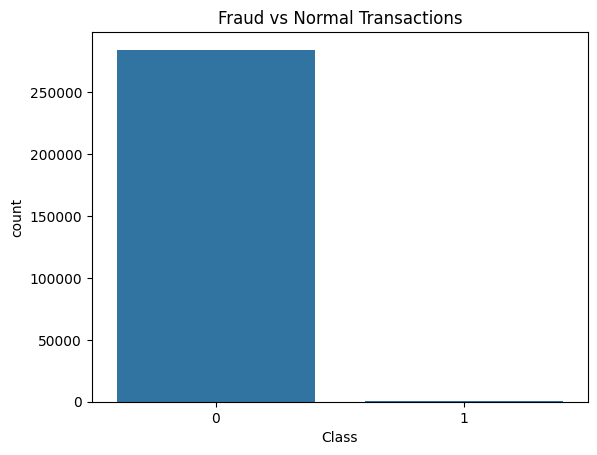

In [5]:
# Bar chart
sns.countplot(x='Class', data=df)
plt.title("Fraud vs Normal Transactions")
plt.show()

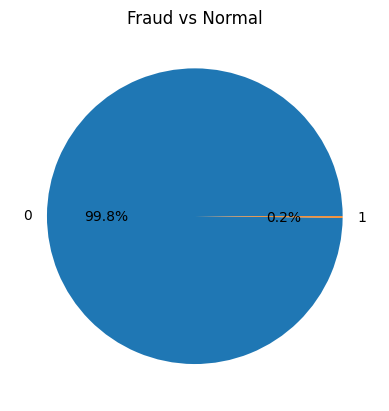

In [6]:
#Pie chart
df['Class'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Fraud vs Normal")
plt.ylabel("")
plt.show()

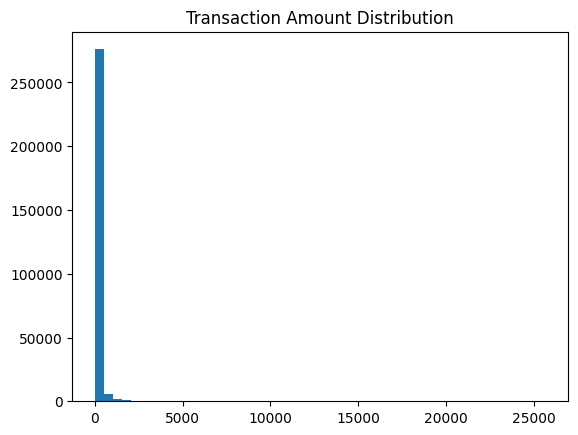

In [7]:
# Histogram
plt.hist(df['Amount'], bins=50)
plt.title("Transaction Amount Distribution")
plt.show()

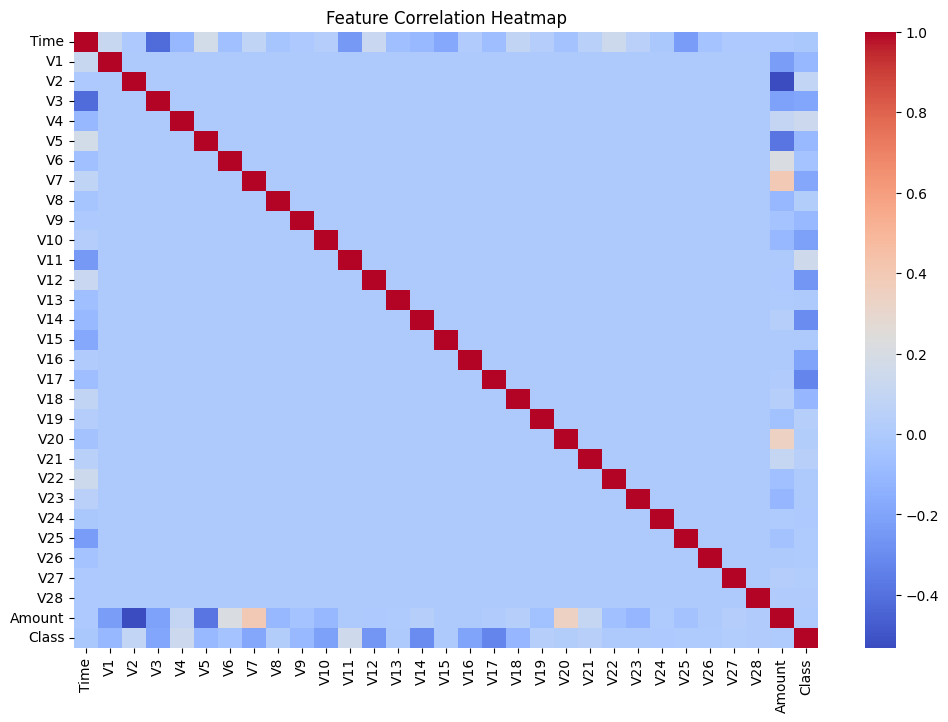

In [8]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

# V1–V28 Feature Distribution Analysis

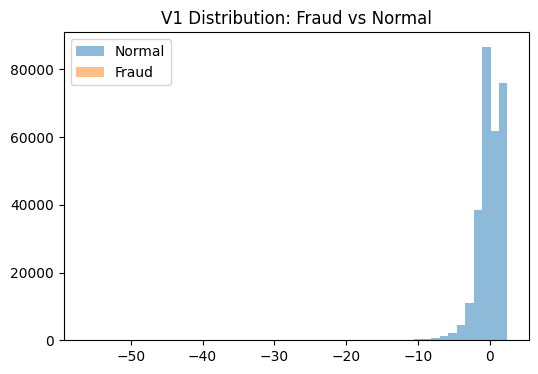

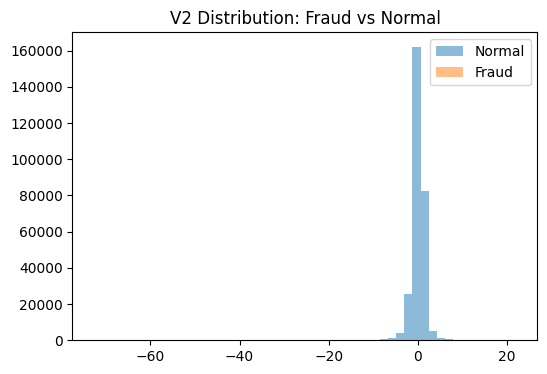

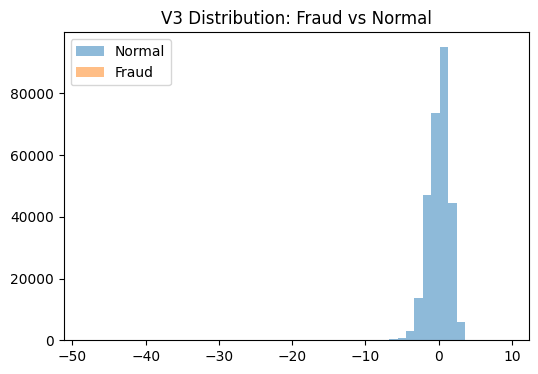

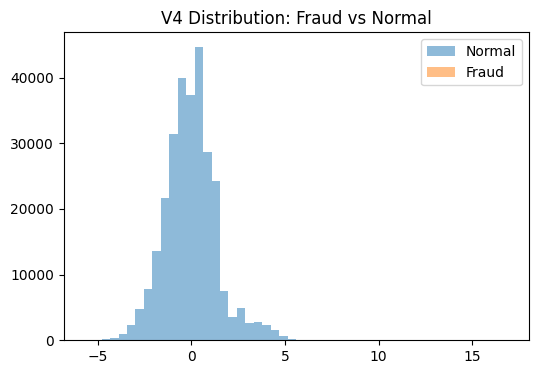

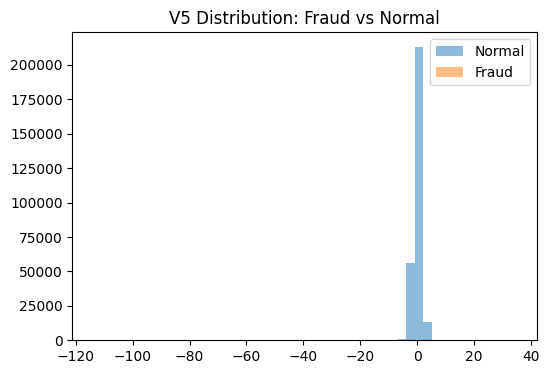

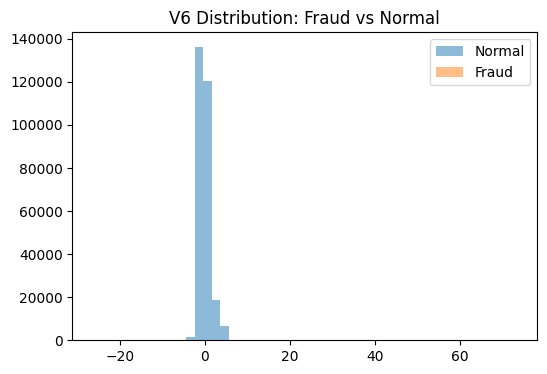

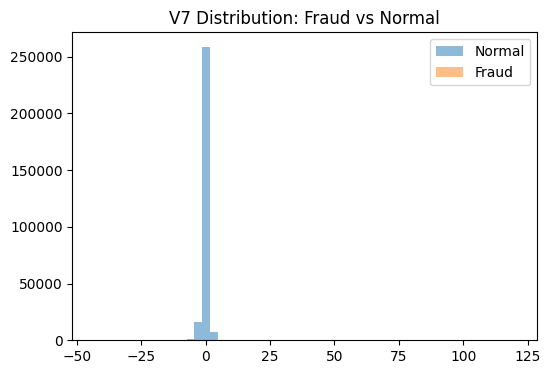

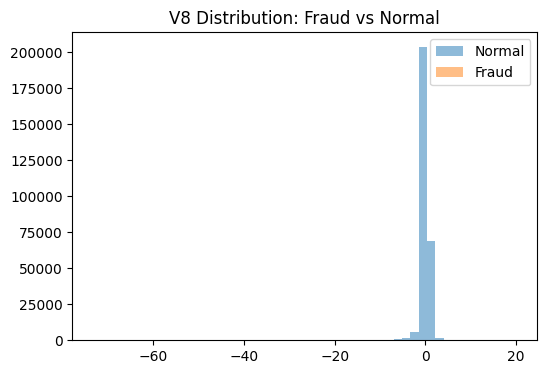

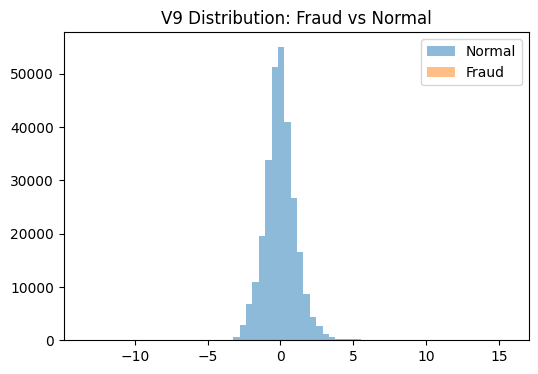

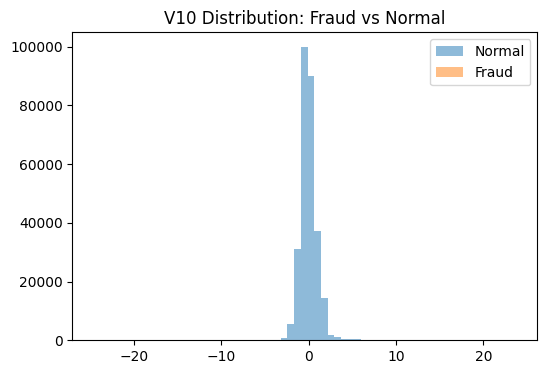

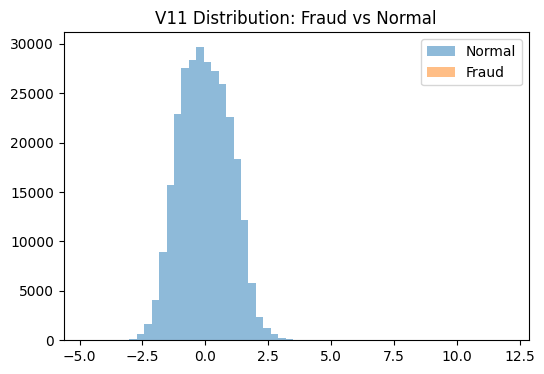

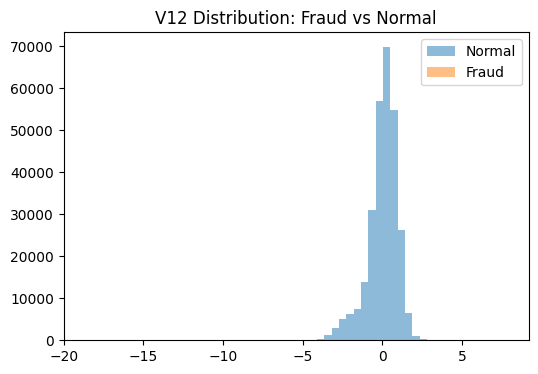

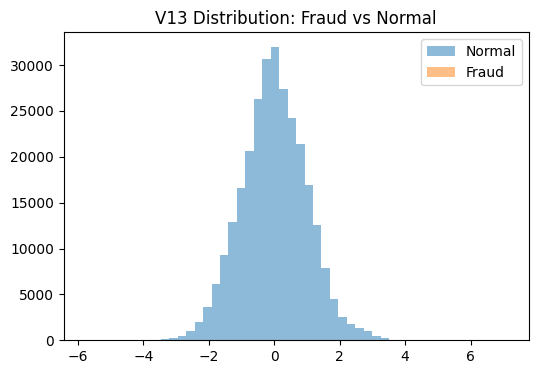

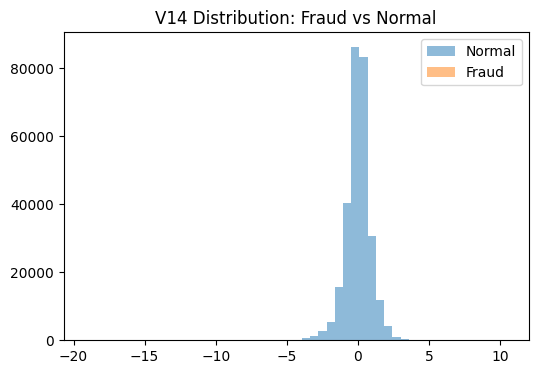

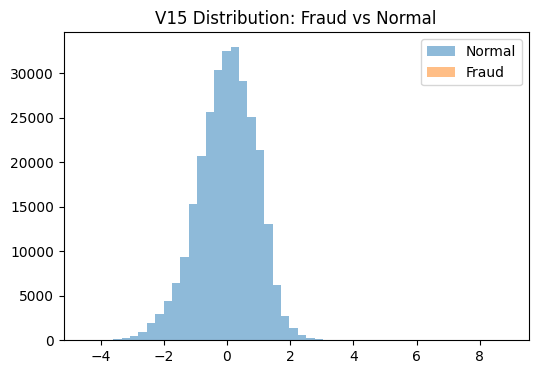

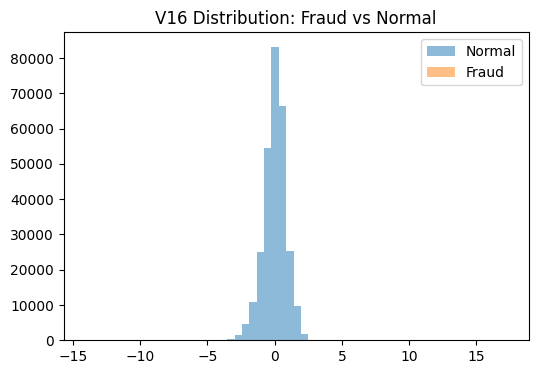

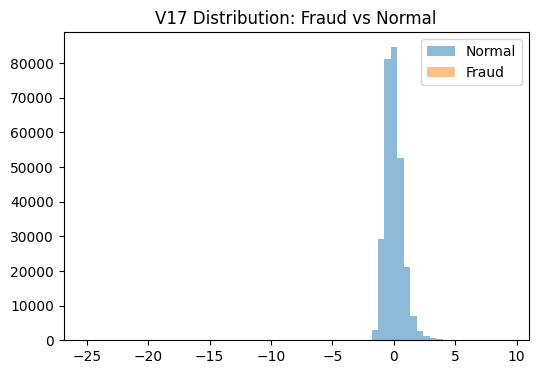

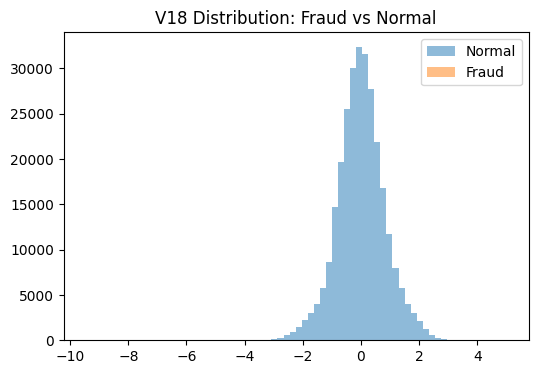

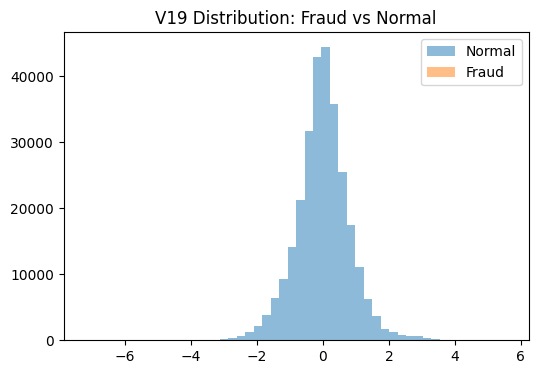

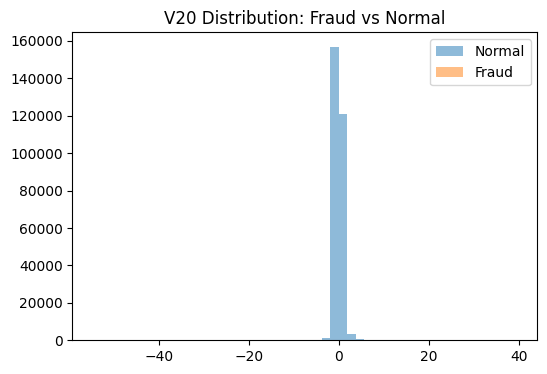

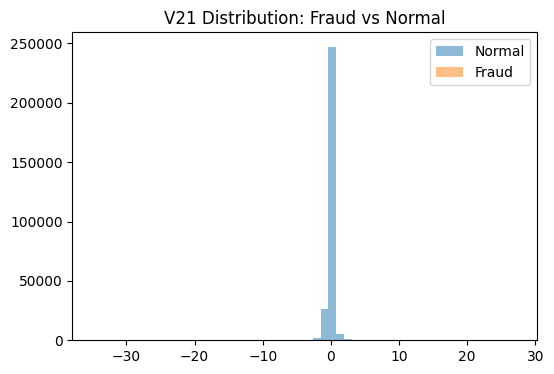

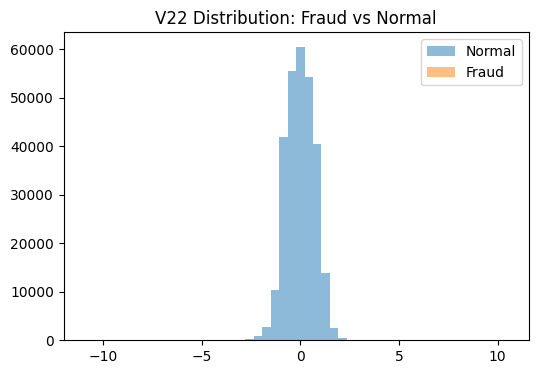

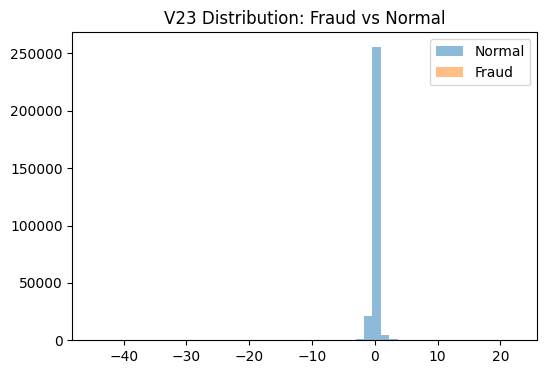

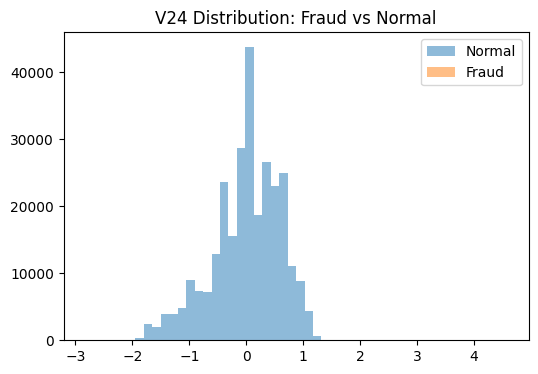

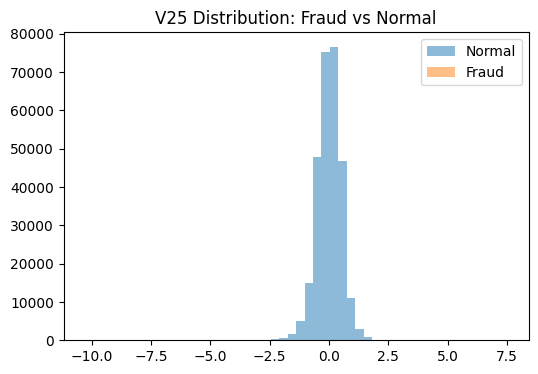

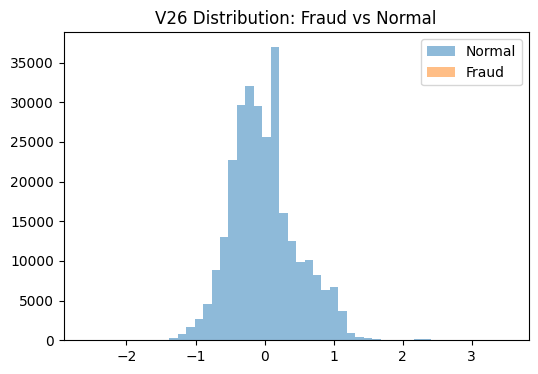

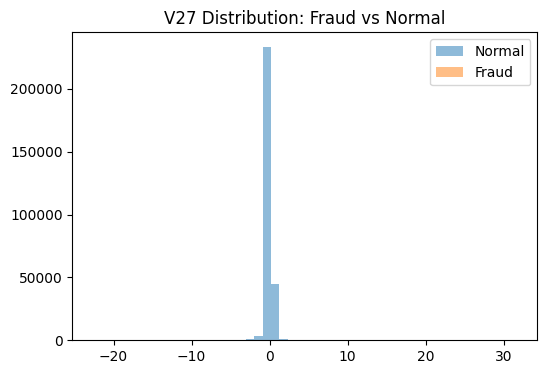

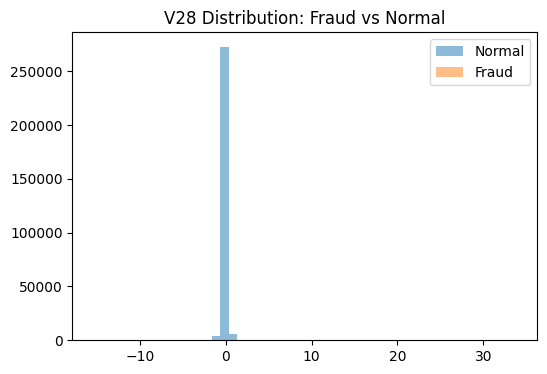

In [9]:

for i in range(1, 29):
    col = 'V' + str(i)
    
    plt.figure(figsize=(6,4))
    plt.hist(df[df['Class']==0][col], bins=50, alpha=0.5, label='Normal')
    plt.hist(df[df['Class']==1][col], bins=50, alpha=0.5, label='Fraud')
    
    plt.legend()
    plt.title(f"{col} Distribution: Fraud vs Normal")
    plt.show()

#  Feature Engineering

In [10]:
# Log transform amount to reduce skewness
df['log_amount'] = np.log1p(df['Amount'])

# Extract hour from time
df['hour'] = df['Time'] // 3600

# Drop original columns
df = df.drop(['Time', 'Amount'], axis=1)

df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,log_amount,hour
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,5.014760,0.0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,1.305626,0.0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,5.939276,0.0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,4.824306,0.0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,4.262539,0.0


In [11]:
X = df.drop('Class', axis=1)
y = df['Class']

# Model Building

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("Logistic Regression Results")
print(classification_report(y_test, y_pred_log))

Logistic Regression Results
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.85      0.58      0.69        98

    accuracy                           1.00     56962
   macro avg       0.93      0.79      0.85     56962
weighted avg       1.00      1.00      1.00     56962



In [14]:
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

print("Decision Tree Results")
print(classification_report(y_test, y_pred_tree))

Decision Tree Results
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.73      0.82      0.77        98

    accuracy                           1.00     56962
   macro avg       0.86      0.91      0.88     56962
weighted avg       1.00      1.00      1.00     56962



In [15]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print("Random Forest Results")
print(classification_report(y_test, y_pred_rf))

Random Forest Results
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.79      0.87        98

    accuracy                           1.00     56962
   macro avg       0.98      0.89      0.93     56962
weighted avg       1.00      1.00      1.00     56962



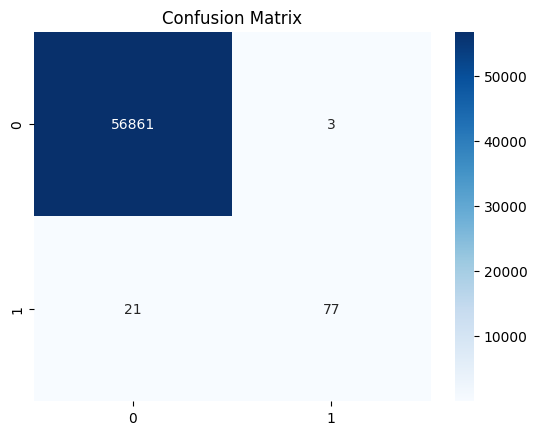

In [17]:
# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_rf),
            annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

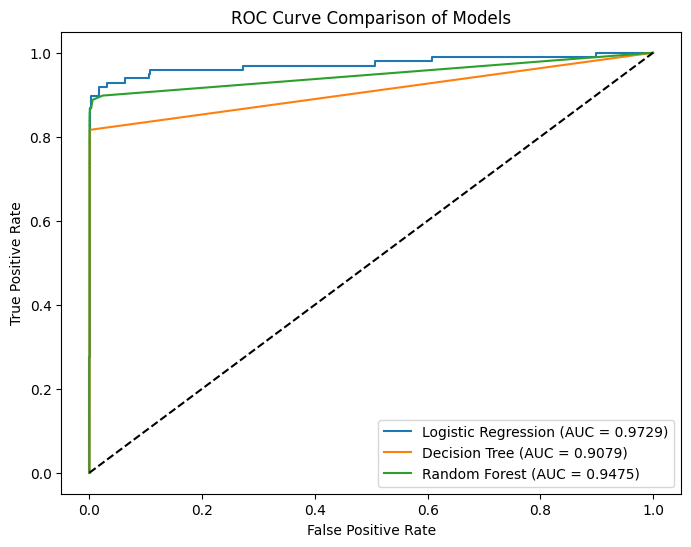

In [18]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get probability scores
y_probs_log = log_model.predict_proba(X_test)[:, 1]
y_probs_tree = tree_model.predict_proba(X_test)[:, 1]
y_probs_rf = rf_model.predict_proba(X_test)[:, 1]

# Calculate ROC curve values
fpr_log, tpr_log, _ = roc_curve(y_test, y_probs_log)
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_probs_tree)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_probs_rf)

# Calculate AUC scores
auc_log = roc_auc_score(y_test, y_probs_log)
auc_tree = roc_auc_score(y_test, y_probs_tree)
auc_rf = roc_auc_score(y_test, y_probs_rf)

# Plot all ROC curves
plt.figure(figsize=(8,6))

plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC = {auc_log:.4f})")
plt.plot(fpr_tree, tpr_tree, label=f"Decision Tree (AUC = {auc_tree:.4f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.4f})")

plt.plot([0,1], [0,1], 'k--')  # Diagonal line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison of Models")
plt.legend()
plt.show()

In [19]:
from sklearn.metrics import accuracy_score, recall_score, precision_score

models = {
    "Logistic Regression": y_pred_log,
    "Decision Tree": y_pred_tree,
    "Random Forest": y_pred_rf
}

for name, preds in models.items():
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, preds))
    print("Precision:", precision_score(y_test, preds))
    print("Recall:", recall_score(y_test, preds))


Logistic Regression
Accuracy: 0.9991046662687406
Precision: 0.8507462686567164
Recall: 0.5816326530612245

Decision Tree
Accuracy: 0.9991573329588147
Precision: 0.7272727272727273
Recall: 0.8163265306122449

Random Forest
Accuracy: 0.9995786664794073
Precision: 0.9625
Recall: 0.7857142857142857


In [20]:
cm = confusion_matrix(y_test, y_pred_rf)
TN, FP, FN, TP = cm.ravel()

print("Total Fraud Cases:", TP + FN)
print("Frauds Detected:", TP)
print("Fraud Detection Rate (Recall):", TP / (TP + FN))

Total Fraud Cases: 98
Frauds Detected: 77
Fraud Detection Rate (Recall): 0.7857142857142857


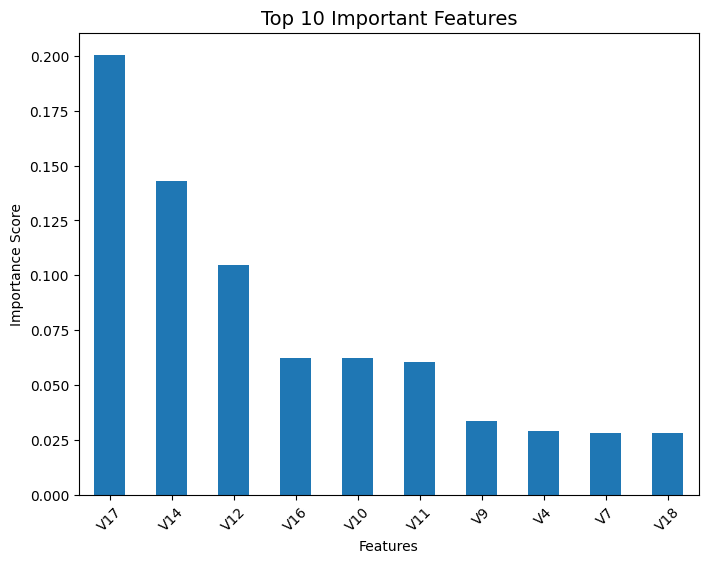

In [21]:
importance = pd.Series(rf_model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

plt.figure(figsize=(8,6))
importance.head(10).plot(kind='bar')

plt.title("Top 10 Important Features", fontsize=14)
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.xticks(rotation=45)
plt.show()

In [ ]:
#  Final Conclusion

- The dataset contains 284,807 transactions with only 0.17% fraud cases.
- Due to heavy class imbalance, recall and ROC-AUC were prioritized.
- Random Forest achieved the best performance.
- The model successfully detected the majority of fraudulent transactions.
- This system can assist financial institutions in identifying suspicious transactions.